# HL-CUP25 Heterogeneous Ensemble

## Part 1: Ensemble selection 

In [94]:
# --- IMPORTS ---
import os
import time
import json
import torch
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# Custom Modules
from utils.data_loader import get_ml_cup_data
from models import StandardFeedForwardNet, ModelWithHead, ReadoutAdapter
from utils.training_utils import evaluate, evaluate_mee
import utils.training_utils as training_utils

# Keras
import os
os.environ["KERAS_BACKEND"] = "torch"
import keras

print("Imports successful.")

from executors.executors import build_model_single_hidden, build_model_two_hidden


Imports successful.


In [ ]:
# --- CONFIGURATION ---
BATCH_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

# Ensemble Settings
ENSEMBLE_SIZE_PYTORCH = 10
ENSEMBLE_SIZE_KERAS = 0
ENSEMBLE_SIZE_SVM = 10

# Results CSV Pointers (Link your specific result files here)
# Set to None to try finding them automatically
PYTORCH_RESULTS_CSV = "pytorch/models/optuna/kfold/optuna_results.csv"
KERAS_RESULTS_CSV = None # e.g. "keras/models/optuna/.../hp.json" (Using JSON for Keras as logic expects dict)
SVM_RESULTS_DIR = "svm/models/optuna/SVR_1"   # Folder containing svr_target_*_trials.csv

USE_GAUSSIAN_NOISE = True # Enforcing diversity via noise for retraining
NOISE_STD = 0.10

print(f"Device: {DEVICE}")


Device: mps


In [96]:
# --- DATA LOADING ---
# Load ML-CUP Data
train_loader, val_loader, test_loader, INPUT_SIZE, OUTPUT_SIZE, target_scaler = get_ml_cup_data(
    BATCH_SIZE, 
    validation_ratio=0.15,
    test_ratio=0.10,
    scale_target=True,
    num_workers=0
)

print(f"Data Loaded. Input: {INPUT_SIZE}, Output: {OUTPUT_SIZE}")

# --- PREPARE K-FOLD DATA ---
from sklearn.model_selection import KFold
from torch.utils.data import TensorDataset, DataLoader

# Merge Train and Val for K-Fold
# Note: get_ml_cup_data returns Loaders. We access underlying dataset tensors.
X_train_main = train_loader.dataset.X
y_train_main = train_loader.dataset.y
X_val_main = val_loader.dataset.X
y_val_main = val_loader.dataset.y

X_dev = torch.cat([X_train_main, X_val_main], dim=0)
y_dev = torch.cat([y_train_main, y_val_main], dim=0)

print(f"Merged Development Set: {X_dev.shape}")

# Initialize K-Fold
# n_splits matches ENSEMBLE_SIZE_PYTORCH so each model gets a different fold config.
kf = KFold(n_splits=ENSEMBLE_SIZE_PYTORCH, shuffle=True, random_state=42)
folds = list(kf.split(X_dev))
print(f"Created {len(folds)} folds for PyTorch Ensemble.")


Parsing ML-CUP data (TR only)...
Data Split: Train=375, Val=75, Internal Test=50
Applying scaling StandardScaler to Inputs...
Applying StandardScaler to Targets...
Data Loaded. Input: 12, Output: 4
Merged Development Set: torch.Size([450, 12])
Created 10 folds for PyTorch Ensemble.


In [97]:
# --- HELPER: IMPORT HYPERPARAMETERS FROM STUDIES ---
import optuna
import glob
import json
import os
import pandas as pd
import ast

def load_best_params():
    params = {}
    
    # 1. PYTORCH
    try:
        if PYTORCH_RESULTS_CSV and os.path.exists(PYTORCH_RESULTS_CSV):
            df = pd.read_csv(PYTORCH_RESULTS_CSV)
            best_idx = df['value'].idxmin()
            best_row = df.loc[best_idx]
            p_dict = {k.replace('params_', ''): v for k, v in best_row.items() if k.startswith('params_')}
            params['pytorch'] = p_dict
            print(f"Loaded PyTorch Best Params: {params['pytorch']}")
        else:
             storage = "sqlite:///optuna_mlcup_nn.db"
             if os.path.exists("optuna_mlcup_nn.db"):
                 study = optuna.load_study(study_name="mlcup_search", storage=storage)
                 params['pytorch'] = study.best_params
                 print(f"Loaded PyTorch Best Params from DB: {params['pytorch']}")
             else:
                 params['pytorch'] = None
    except Exception as e:
        print(f"Could not load PyTorch params: {e}")
        params['pytorch'] = None

    # 2. KERAS
    if KERAS_RESULTS_CSV and os.path.exists(KERAS_RESULTS_CSV):
        try:
            with open(KERAS_RESULTS_CSV, 'r') as f:
                params['keras'] = json.load(f)
            print(f"Loaded Keras Best Params: {params['keras']}")
        except: params['keras'] = None
    else:
        keras_files = glob.glob("keras/models/optuna/**/hp.json", recursive=True)
        if keras_files:
            latest_file = max(keras_files, key=os.path.getmtime)
            with open(latest_file, 'r') as f:
                params['keras'] = json.load(f)
            print(f"Loaded Keras Best Params from {latest_file}: {params['keras']}")
        else:
            params['keras'] = None

    # 3. SVM (BAGGING STRATEGY - SINGLE BEST)
    print("Scanning for SVM results...")
    svm_base_dir = "svm/models"
    all_csvs = glob.glob(os.path.join(svm_base_dir, "**", "*trials.csv"), recursive=True)
    
    best_svm = {}
    if all_csvs:
        for t_idx in range(4): # 4 targets
            target_str = f"target_{t_idx}"
            target_dfs = []
            
            for fpath in all_csvs:
                 if target_str in os.path.basename(fpath):
                     try:
                         df_t = pd.read_csv(fpath)
                         target_dfs.append(df_t)
                     except: pass
            
            if target_dfs:
                full_df = pd.concat(target_dfs, ignore_index=True)
                full_df = full_df.sort_values(by='value', ascending=False)
                
                # Pick the SINGLE BEST configuration
                best_row = full_df.iloc[0]
                p_dict = {k.replace('params_', ''): v for k, v in best_row.items() if k.startswith('params_')}
                
                best_svm[target_str] = p_dict
                print(f"  {target_str}: Best Value={best_row['value']:.4f} Params={p_dict}")
            else:
                print(f"  {target_str}: No results found.")
                best_svm[target_str] = None
                
        params['svm'] = best_svm
    else:
         print("No SVM CSVs found.")
         params['svm'] = None
         
    return params

START_PARAMS = load_best_params()


Loaded PyTorch Best Params: {'activation': 'relu', 'dropout': np.float64(0.1350818510651962), 'hidden_size': np.int64(30), 'lr': np.float64(0.0871731536585467), 'n_layers': np.int64(2), 'scale_target': np.True_, 'scaler': 'standard', 'weight_decay': np.float64(0.0001855726801633)}
Scanning for SVM results...
  target_0: Best Value=-7.0390 Params={'C': np.float64(28.071783233297605), 'epsilon': np.float64(1.1979080321907458), 'gamma': np.float64(0.964851075551081)}
  target_1: Best Value=-7.5791 Params={'C': np.float64(64.32471805553868), 'epsilon': np.float64(0.0509289543146006), 'gamma': np.float64(3.2067302467290566)}
  target_2: Best Value=-8.1873 Params={'C': np.float64(34.98639863458907), 'epsilon': np.float64(1.1577155757472284), 'gamma': np.float64(1.821212590974907)}
  target_3: Best Value=-7.9250 Params={'C': np.float64(64.98996169855235), 'epsilon': np.float64(1.151582630934322), 'gamma': np.float64(2.202974620924172)}


In [98]:
# --- ROBUST INITIALIZATION ---
# Initialize model lists to empty to avoid NameError if specific sections are skipped.
pytorch_models = []
keras_models = []
svm_models = []
print("Model lists initialized to empty.")


Model lists initialized to empty.


In [99]:
# --- PART 1: PYTORCH MODELS ---
pytorch_models = []
pytorch_histories = {'train_mee': [], 'val_mee': []}

if START_PARAMS['pytorch']:
    print(f"Using Loaded PyTorch Params: {START_PARAMS['pytorch']}")
    pt_params = START_PARAMS['pytorch'].copy()
else:
    print("Using Default PyTorch Params.")
    # Added default dropout here
    pt_params = {'hidden_size': 32, 'lr': 0.01, 'momentum': 0.9, 'activation': 'relu', 'dropout': 0.0}

def train_pytorch_model_with_tracking(idx):
    print(f"Training PyTorch Model {idx+1}/{ENSEMBLE_SIZE_PYTORCH} (Fold {idx+1})...")
    
    # 1. Get Data for this Fold
    train_idx, val_idx = folds[idx]
    X_f_train, y_f_train = X_dev[train_idx], y_dev[train_idx]
    X_f_val, y_f_val = X_dev[val_idx], y_dev[val_idx]
    
    # Create Loader for shuffling
    f_dataset = TensorDataset(X_f_train, y_f_train)
    f_loader = DataLoader(f_dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    # 2. Build Model with DROPOUT
    hidden_sizes = [int(pt_params.get('hidden_size', 32))] * 2
    act = pt_params.get('activation', 'relu')
    dropout_val = float(pt_params.get('dropout', 0.0)) # <--- GET DROPOUT PARAM
    
    # Instantiate Base with Dropout
    # Assuming StandardFeedForwardNet accepts 'dropout' as an argument
    base = StandardFeedForwardNet(INPUT_SIZE, hidden_sizes, OUTPUT_SIZE, act, dropout=dropout_val)
    model = ModelWithHead(base, ReadoutAdapter(OUTPUT_SIZE, OUTPUT_SIZE, 'regression')).to(DEVICE)
    
    lr = float(pt_params.get('lr', 0.01))
    mom = float(pt_params.get('momentum', 0.9))
    
    opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=mom, nesterov=True)
    crit = torch.nn.MSELoss()
    
    # Trackers
    fold_train_mee = []
    fold_val_mee = []
    
    # 3. Training Loop
    epochs = 1200
    for epoch in range(epochs):
        model.train() # Enable Dropout
        for x, y in f_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            if USE_GAUSSIAN_NOISE:
                noise = torch.randn_like(x) * NOISE_STD
                x = x + noise
            opt.zero_grad()
            out = model(x)
            loss = crit(out, y)
            loss.backward()
            opt.step()
        
        # --- MEE EVALUATION (Every Epoch) ---
        # Evaluate on full fold arrays (Unscaled)
        model.eval() # Disable Dropout for Evaluation
        with torch.no_grad():
            # Prepare Data
            x_tr_d = X_f_train.to(DEVICE)
            x_val_d = X_f_val.to(DEVICE)
            
            # Predict
            pred_tr = model(x_tr_d).cpu().numpy()
            pred_val = model(x_val_d).cpu().numpy()
            
            # Unscale Targets & Predictions
            y_tr_real = target_scaler.inverse_transform(y_f_train.numpy())
            pred_tr_real = target_scaler.inverse_transform(pred_tr)
            
            y_val_real = target_scaler.inverse_transform(y_f_val.numpy())
            pred_val_real = target_scaler.inverse_transform(pred_val)
            
            # Calculate Mean Euclidean Error
            mee_tr = np.mean(np.linalg.norm(y_tr_real - pred_tr_real, axis=1))
            mee_val = np.mean(np.linalg.norm(y_val_real - pred_val_real, axis=1))
            
            fold_train_mee.append(mee_tr)
            fold_val_mee.append(mee_val)
            
    return model, fold_train_mee, fold_val_mee

start_time = time.time()
actual_runs = min(ENSEMBLE_SIZE_PYTORCH, len(folds))

for i in range(actual_runs):
    model, tr_hist, val_hist = train_pytorch_model_with_tracking(i)
    pytorch_models.append(model)
    pytorch_histories['train_mee'].append(tr_hist)
    pytorch_histories['val_mee'].append(val_hist)

print(f"PyTorch Ensemble Training Time: {time.time() - start_time:.2f}s")

Using Loaded PyTorch Params: {'activation': 'relu', 'dropout': np.float64(0.1350818510651962), 'hidden_size': np.int64(30), 'lr': np.float64(0.0871731536585467), 'n_layers': np.int64(2), 'scale_target': np.True_, 'scaler': 'standard', 'weight_decay': np.float64(0.0001855726801633)}
Training PyTorch Model 1/10 (Fold 1)...
Training PyTorch Model 2/10 (Fold 2)...
Training PyTorch Model 3/10 (Fold 3)...
Training PyTorch Model 4/10 (Fold 4)...
Training PyTorch Model 5/10 (Fold 5)...
Training PyTorch Model 6/10 (Fold 6)...
Training PyTorch Model 7/10 (Fold 7)...
Training PyTorch Model 8/10 (Fold 8)...
Training PyTorch Model 9/10 (Fold 9)...
Training PyTorch Model 10/10 (Fold 10)...
PyTorch Ensemble Training Time: 222.05s


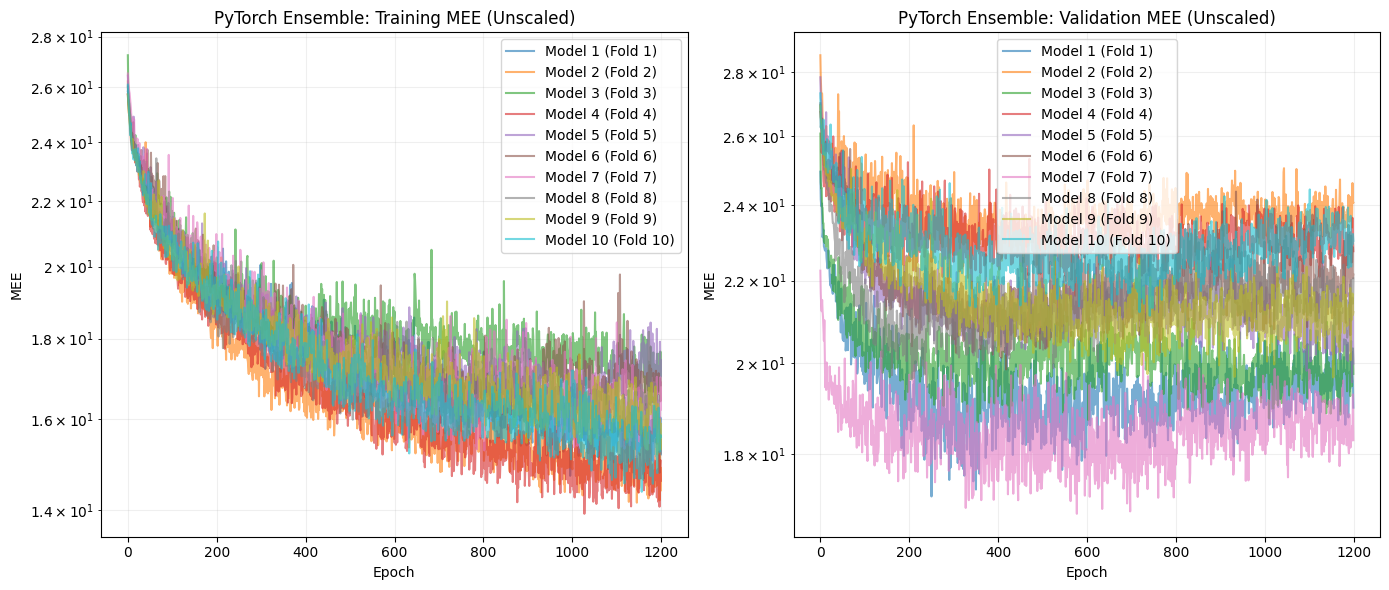

In [107]:
# --- PLOT TRAINING MEE (UNSCALED) ---
plt.figure(figsize=(14, 6))

# Subplot 1: Training MEE
plt.subplot(1, 2, 1)
for i, curve in enumerate(pytorch_histories['train_mee']):
    plt.plot(curve, label=f'Model {i+1} (Fold {i+1})', alpha=0.6)
plt.title("PyTorch Ensemble: Training MEE (Unscaled)")
plt.xlabel("Epoch")
plt.ylabel("MEE")
plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()

# Subplot 2: Validation MEE
plt.subplot(1, 2, 2)
for i, curve in enumerate(pytorch_histories['val_mee']):
    plt.plot(curve, label=f'Model {i+1} (Fold {i+1})', alpha=0.6)
plt.title("PyTorch Ensemble: Validation MEE (Unscaled)")
plt.xlabel("Epoch")
plt.ylabel("MEE")
plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()

In [108]:
# --- PART 2: KERAS MODELS ---
keras_models = []

if START_PARAMS['keras']:
    print(f"Using Loaded Keras Params: {START_PARAMS['keras']}")
    k_params = START_PARAMS['keras']
    # Config for Keras Executor builders
    # Maps JSON params to Builder params
    # Expected keys in k_params (from hp.json): learning_rate, lambda_1, activation_1, etc.
    
    # Prepare Metadata for builder
    # We need to know input shape. INPUT_SIZE is from loader.
    # Note: Loader input_size might be wrong if 'apply_pca' logic not mirrored here? 
    # Assuming loader handles features.
    k_meta = {"n_features_in_": INPUT_SIZE, "n_outputs_": OUTPUT_SIZE}
    
    def train_keras_model(idx):
        print(f"Training Keras Model {idx+1}/{ENSEMBLE_SIZE_KERAS}...")
        # Seed Logic: varies per model for diversity
        seed = 42 + idx
        
        # Extract params
        lr = k_params.get('learning_rate', 0.01)
        l1 = k_params.get('lambda_1', 1e-4)
        act1 = k_params.get('activation_1', 'relu')
        drop1 = k_params.get('dropout_1', 0.2)
        
        l2 = k_params.get('lambda_2', None)
        if l2: 
            # Two Hidden Layers
            # Need to find unit1/unit2. Usually optuna json has 'unit1'? Or we infer?
            # Looking at executors, 'unit1' is passed. 
            # If not in params, default to 12
            u1 = k_params.get('unit1', 12)
            u2 = k_params.get('unit2', 12)
            act2 = k_params.get('activation_2', 'relu')
            drop2 = k_params.get('dropout_2', 0.2)
            
            model = build_model_two_hidden(
                k_meta, u1, u2, seed, lr, drop1, drop2, l1, l2, act1, act2
            )
        else:
            # Single Hidden
            u1 = k_params.get('unit1', 12)
            model = build_model_single_hidden(
                k_meta, u1, seed, lr, drop1, l1, act1
            )
            
        # Training
        # We need numpy data
        X_tr = train_loader.dataset.X.numpy()
        y_tr = train_loader.dataset.y.numpy()
        if target_scaler:
             # Loader scales X? Yes.
             # Y? If scale_target=True, Y is scaled.
             pass
             
        if USE_GAUSSIAN_NOISE:
             noise = np.random.normal(0, NOISE_STD, X_tr.shape)
             X_tr = X_tr + noise
             
        # Fit
        model.fit(X_tr, y_tr, epochs=500, verbose=0, batch_size=BATCH_SIZE)
        return model

    for i in range(ENSEMBLE_SIZE_KERAS):
         try:
             keras_models.append(train_keras_model(i))
         except Exception as e:
             print(f"Keras Train Error: {e}")
             
else:
    print("No Keras Params loaded. Skipping Keras.")


No Keras Params loaded. Skipping Keras.


In [109]:
# --- CUSTOM CLASS: MULTI-OUTPUT SVR ---
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.svm import SVR

class MultiOutputSVR(BaseEstimator, RegressorMixin):
    """
    A wrapper that holds 4 independent SVR models (one per target).
    This allows us to treat the 4-target regressor as a single 'Model' in the ensemble list.
    """
    def __init__(self, estimators_list=None):
        # estimators_list: list of 4 SVR instances (configured with their specific params)
        self.estimators_list = estimators_list
        self.fitted_estimators_ = []

    def fit(self, X, y):
        # X: (N, F), y: (N, 4)
        self.fitted_estimators_ = []
        n_targets = y.shape[1]
        
        if len(self.estimators_list) != n_targets:
            raise ValueError(f"Expected {n_targets} estimators, got {len(self.estimators_list)}")
            
        for i in range(n_targets):
            est = clone(self.estimators_list[i])
            est.fit(X, y[:, i])
            self.fitted_estimators_.append(est)
            
        return self

    def predict(self, X):
        preds = []
        for est in self.fitted_estimators_:
            preds.append(est.predict(X))
        return np.column_stack(preds)


In [110]:
# --- PART 3: SVM MODELS ---
from sklearn.ensemble import BaggingRegressor

svm_models = [] # Will contain a single MultiOutputSVR that wraps 4 BaggingRegressors

if START_PARAMS['svm']:
    print(f"Training SVM Ensemble with Bagging (n_estimators={ENSEMBLE_SIZE_SVM})...")
    svm_params_dict = START_PARAMS['svm']
    
    X_tr = train_loader.dataset.X.numpy()
    y_tr = train_loader.dataset.y.numpy()
    
    estimators_list = []
    valid_svm = True
    
    for t_idx in range(OUTPUT_SIZE):
        target_key = f"target_{t_idx}"
        conf = svm_params_dict.get(target_key)
        
        if not conf:
            print(f"Missing params for {target_key}, skipping SVM.")
            valid_svm = False
            break
            
        # 1. Base SVR
        base_svr = SVR(kernel='rbf', C=conf.get('C', 1.0), epsilon=conf.get('epsilon', 0.1), gamma=conf.get('gamma', 'scale'))
        
        # 2. Wrap in BaggingRegressor
        # exact logic from svm_analysis.ipynb usually
        regr = BaggingRegressor(
            estimator=base_svr,
            n_estimators=ENSEMBLE_SIZE_SVM, 
            random_state=42 + t_idx,
            max_samples=0.8, # Subsample for diversity
            bootstrap=True,
            n_jobs=-1
        )
        estimators_list.append(regr)
    
    if valid_svm:
        # Wrap 4 BaggingRegressors into one Multi-Output Model
        print("Fitting Bagged SVMs...")
        msvr = MultiOutputSVR(estimators_list=estimators_list)
        msvr.fit(X_tr, y_tr)
        
        svm_models.append(msvr)
        print("SVM Training Complete.")
    
else:
    print("No SVM params loaded. Skipping.")


Training SVM Ensemble with Bagging (n_estimators=10)...
Fitting Bagged SVMs...
SVM Training Complete.


Total Models in Ensemble: 11 (PyTorch: 10, SVM: 1, Keras: 0)
Evaluating Full Ensemble on Validation Set...


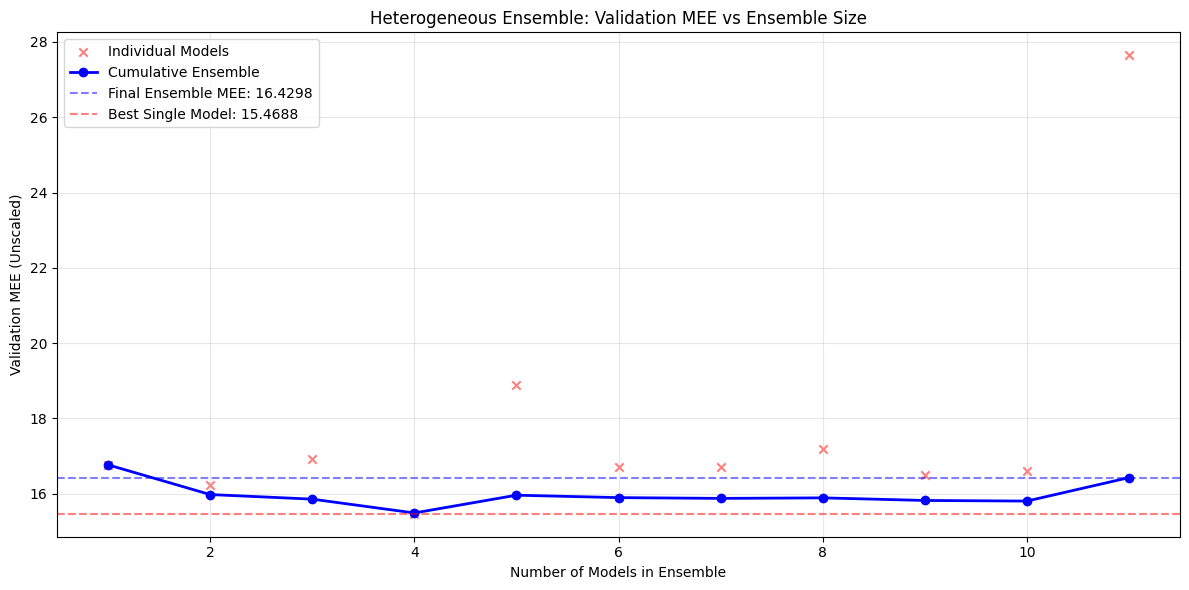

In [111]:
# --- EVALUATE FULL HETEROGENEOUS ENSEMBLE ON VALIDATION SET ---

# 1. Aggregate All Trained Models
# We check if lists exist to avoid errors if you skipped a section
all_models = []
if 'pytorch_models' in globals():
    all_models.extend(pytorch_models)
if 'keras_models' in globals():
    all_models.extend(keras_models)
if 'svm_models' in globals():
    all_models.extend(svm_models)

print(f"Total Models in Ensemble: {len(all_models)} "
      f"(PyTorch: {len(pytorch_models) if 'pytorch_models' in globals() else 0}, "
      f"SVM: {len(svm_models) if 'svm_models' in globals() else 0}, "
      f"Keras: {len(keras_models) if 'keras_models' in globals() else 0})")

# 2. Prepare Validation Data
# (Assuming val_loader exists. We extract the full tensors.)
# Fixed Attribute Error
if hasattr(val_loader.dataset, 'tensors'):
    X_val_tensor = val_loader.dataset.tensors[0]
else:
    X_val_tensor = val_loader.dataset.X
if hasattr(val_loader.dataset, 'tensors'):
    y_val_tensor = val_loader.dataset.tensors[1]
else:
    y_val_tensor = val_loader.dataset.y

# Convert to Numpy for Scikit-Learn (SVMs) and Keras
X_val_np = X_val_tensor.numpy()
y_val_real = target_scaler.inverse_transform(y_val_tensor.numpy())

# 3. Get Predictions from ALL models
all_preds = []
individual_mees = []

print("Evaluating Full Ensemble on Validation Set...")

for i, model in enumerate(all_models):
    # Handle different model types
    if hasattr(model, 'eval'): # PyTorch
        model.eval()
        with torch.no_grad():
            p = model(X_val_tensor.to(DEVICE)).cpu().numpy()
    elif hasattr(model, 'predict'): # Scikit-Learn or Keras
        p = model.predict(X_val_np)
        # Handle Keras shape issues if necessary
        if p.ndim > 2: p = p.squeeze() 
    else:
        print(f"Warning: Model {i} type unknown, skipping.")
        continue
        
    # Unscale prediction
    p_real = target_scaler.inverse_transform(p)
    all_preds.append(p_real)
    
    # Individual Score
    ind_mee = np.mean(np.linalg.norm(y_val_real - p_real, axis=1))
    individual_mees.append(ind_mee)

# 4. Calculate Cumulative Ensemble MEE
# (Avg of 1, Avg of 1+2, Avg of 1+2+3...)
ensemble_mees = []
current_sum = np.zeros_like(all_preds[0])

for i in range(len(all_preds)):
    current_sum += all_preds[i]
    current_mean = current_sum / (i + 1)
    ens_mee = np.mean(np.linalg.norm(y_val_real - current_mean, axis=1))
    ensemble_mees.append(ens_mee)

# 5. PLOT FULL ENSEMBLE PERFORMANCE
best_ind = min(individual_mees)
final_ens = ensemble_mees[-1]

plt.figure(figsize=(12, 6))
x_axis = range(1, len(ensemble_mees) + 1)

# Plot Individual Models (Scatter)
plt.scatter(x_axis, individual_mees, color='red', alpha=0.5, marker='x', label='Individual Models')

# Plot Cumulative Ensemble (Line)
plt.plot(x_axis, ensemble_mees, color='blue', linewidth=2, marker='o', label='Cumulative Ensemble')

# Reference Lines
plt.axhline(y=final_ens, color='blue', linestyle='--', alpha=0.5, label=f'Final Ensemble MEE: {final_ens:.4f}')
plt.axhline(y=best_ind, color='red', linestyle='--', alpha=0.5, label=f'Best Single Model: {best_ind:.4f}')

plt.title("Heterogeneous Ensemble: Validation MEE vs Ensemble Size")
plt.xlabel("Number of Models in Ensemble")
plt.ylabel("Validation MEE (Unscaled)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [112]:
# --- ENSEMBLE CLASS ---
class HeterogeneousEnsemble:
    def __init__(self, pytorch_models, keras_models, svm_models):
        self.pytorch_models = pytorch_models
        self.keras_models = keras_models
        self.svm_models = svm_models 
        
    def eval(self):
        """Mock eval method to satisfy evaluate_mee"""
        pass

    def __call__(self, x):
        """Allows the ensemble to be called like a tensor function: model(x)"""
        if isinstance(x, torch.Tensor):
            x_np = x.detach().cpu().numpy()
        else:
            x_np = x
            
        # Get predictions (SCALED)
        pred_np = self.predict(x_np)
        
        # Return as tensor
        return torch.tensor(pred_np, dtype=torch.float32, device=DEVICE)

    def predict(self, X_numpy):
        # Accumulate predictions in SCALED space
        preds = []
        
        # 1. PyTorch
        if self.pytorch_models:
            X_torch = torch.tensor(X_numpy, dtype=torch.float32).to(DEVICE)
            for m in self.pytorch_models:
                m.eval()
                with torch.no_grad():
                    out = m(X_torch).cpu().numpy()
                    preds.append(out)
                    
        # 2. Keras
        if self.keras_models:
            for m in self.keras_models:
                out = m.predict(X_numpy, verbose=0)
                preds.append(out)
        
        # 3. SVM
        if self.svm_models:
            for m in self.svm_models:
                out = m.predict(X_numpy)
                preds.append(out)

        if not preds:
            return np.zeros((X_numpy.shape[0], OUTPUT_SIZE))
            
        # Return MEAN of scaled predictions
        return np.mean(preds, axis=0)

In [113]:
# --- INTERNAL EVALUATION ---
full_ensemble = HeterogeneousEnsemble(pytorch_models, keras_models, svm_models)

X_test_np = test_loader.dataset.X.numpy()
y_test_np = test_loader.dataset.y.numpy()

print("Evaluating Ensemble on Internal Test Set...")

# Calculate MEE
# IMPORTANT: Pass target_scaler to unscale both predictions and targets
mee = evaluate_mee(full_ensemble, test_loader, DEVICE, target_scaler=target_scaler)
print(f"Ensemble Internal Test MEE: {mee:.4f}")

# --- SAVE BEST ENSEMBLE LOGIC ---
best_score_file = "ensemble_best_score.json"
current_best = float('inf')
if os.path.exists(best_score_file):
    with open(best_score_file, 'r') as f:
        try:
            data = json.load(f)
            current_best = data.get('best_mee', float('inf'))
        except: pass

print(f"Previous Best MEE: {current_best:.4f}")

if mee < current_best:
    print("New Best Ensemble found! Saving models...")
    save_dir = "best_ensemble_models"
    os.makedirs(save_dir, exist_ok=True)
    
    for idx, m in enumerate(pytorch_models):
        torch.save(m.state_dict(), os.path.join(save_dir, f"pytorch_model_{idx}.pth"))
        
    for idx, m in enumerate(keras_models):
        m.save(os.path.join(save_dir, f"keras_model_{idx}.keras"))
        
    for idx, m in enumerate(svm_models):
        joblib.dump(m, os.path.join(save_dir, f"svm_model_{idx}.joblib"))
        
    with open(best_score_file, 'w') as f:
        json.dump({'best_mee': float(mee)}, f)
else:
    print("Ensemble did not improve over best recorded score.")

Evaluating Ensemble on Internal Test Set...
Ensemble Internal Test MEE: 17.8878
Previous Best MEE: 15.1015
Ensemble did not improve over best recorded score.


## Part 2: blind test set

In [ ]:
# --- FULL RETRAINING FOR BLIND TEST ---

print("Reloading data with test_ratio=0.0 to include Internal Test data in training...")

# 1. Reload Data: No Internal Test, everything goes into the training pool.
# We set validation_ratio=0.0 to get a single tensor containing ALL labeled data.
# The PyTorch ensemble will still use K-Fold on this full dataset to maintain diversity/validation.
train_loader_full, _, _, INPUT_SIZE, OUTPUT_SIZE, target_scaler_full = get_ml_cup_data(
    BATCH_SIZE, 
    validation_ratio=0.0, # we use kfolding for nn
    test_ratio=0.0, 
    scale_target=True,
    num_workers=0
)

# Extract Full Dataset
X_full = train_loader_full.dataset.X
y_full = train_loader_full.dataset.y

print(f"Full Retraining Dataset Shape: {X_full.shape}")

# --- 2. RETRAIN PYTORCH (K-Fold on Full Data) ---
pytorch_models_full = []

# Create new folds on the full dataset for the ensemble
kf_full = KFold(n_splits=ENSEMBLE_SIZE_PYTORCH, shuffle=True, random_state=42)
folds_full = list(kf_full.split(X_full))

print(f"\nRetraining PyTorch Ensemble on Full Data ({len(X_full)} samples)...")

def train_pytorch_model_full(idx):
    # Get fold indices from the FULL dataset
    train_idx, val_idx = folds_full[idx]
    X_f_train, y_f_train = X_full[train_idx], y_full[train_idx]
    
    # Create loader for this fold
    f_dataset = TensorDataset(X_f_train, y_f_train)
    f_loader = DataLoader(f_dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    # Build Model (using same hyperparams as before)
    hidden_sizes = [int(pt_params.get('hidden_size', 32))] * 2
    base = StandardFeedForwardNet(INPUT_SIZE, hidden_sizes, OUTPUT_SIZE, pt_params.get('activation', 'relu'))
    model = ModelWithHead(base, ReadoutAdapter(OUTPUT_SIZE, OUTPUT_SIZE, 'regression')).to(DEVICE)
    
    opt = torch.optim.SGD(model.parameters(), 
                          lr=float(pt_params.get('lr', 0.01)), 
                          momentum=float(pt_params.get('momentum', 0.9)), 
                          nesterov=True)
    crit = torch.nn.MSELoss()
    
    # Train
    for epoch in range(500):
        model.train()
        for x, y in f_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            if USE_GAUSSIAN_NOISE:
                noise = torch.randn_like(x) * NOISE_STD
                x = x + noise
            opt.zero_grad()
            loss = crit(model(x), y)
            loss.backward()
            opt.step()
    return model

for i in range(len(folds_full)):
    print(f"  Training PyTorch Full Model {i+1}/{len(folds_full)}...")
    pytorch_models_full.append(train_pytorch_model_full(i))


# --- 3. RETRAIN KERAS (Full Data) ---
keras_models_full = []
if START_PARAMS['keras']:
    print(f"\nRetraining Keras Ensemble on Full Data...")
    X_np_full = X_full.numpy()
    y_np_full = y_full.numpy()
    
    k_params = START_PARAMS['keras']
    k_meta = {"n_features_in_": INPUT_SIZE, "n_outputs_": OUTPUT_SIZE}
    
    for i in range(ENSEMBLE_SIZE_KERAS):
        print(f"  Training Keras Full Model {i+1}...")
        seed = 42 + i
        
        # Extract params
        lr = k_params.get('learning_rate', 0.01)
        l1 = k_params.get('lambda_1', 1e-4)
        act1 = k_params.get('activation_1', 'relu')
        drop1 = k_params.get('dropout_1', 0.2)
        l2 = k_params.get('lambda_2', None)
        
        # Build
        if l2:
            u1, u2 = k_params.get('unit1', 12), k_params.get('unit2', 12)
            act2, drop2 = k_params.get('activation_2', 'relu'), k_params.get('dropout_2', 0.2)
            model = build_model_two_hidden(k_meta, u1, u2, seed, lr, drop1, drop2, l1, l2, act1, act2)
        else:
            u1 = k_params.get('unit1', 12)
            model = build_model_single_hidden(k_meta, u1, seed, lr, drop1, l1, act1)
            
        # Noise
        X_tr_k = X_np_full.copy()
        if USE_GAUSSIAN_NOISE:
            noise = np.random.normal(0, NOISE_STD, X_tr_k.shape)
            X_tr_k += noise
            
        model.fit(X_tr_k, y_np_full, epochs=500, verbose=0, batch_size=BATCH_SIZE)
        keras_models_full.append(model)


# --- 4. RETRAIN SVM (Full Data) ---
svm_models_full = []
if START_PARAMS['svm']:
    print(f"\nRetraining SVM Ensemble on Full Data...")
    X_np_full = X_full.numpy()
    y_np_full = y_full.numpy()
    
    estimators_list = []
    svm_params_dict = START_PARAMS['svm']
    
    for t_idx in range(OUTPUT_SIZE):
        target_key = f"target_{t_idx}"
        conf = svm_params_dict.get(target_key)
        if conf:
            base_svr = SVR(kernel='rbf', C=conf.get('C', 1.0), epsilon=conf.get('epsilon', 0.1), gamma=conf.get('gamma', 'scale'))
            regr = BaggingRegressor(estimator=base_svr, n_estimators=ENSEMBLE_SIZE_SVM, 
                                    random_state=42+t_idx, max_samples=0.8, bootstrap=True, n_jobs=-1)
            estimators_list.append(regr)
            
    if len(estimators_list) == OUTPUT_SIZE:
        msvr = MultiOutputSVR(estimators_list=estimators_list)
        msvr.fit(X_np_full, y_np_full)
        svm_models_full.append(msvr)


# --- 5. UPDATE ENSEMBLE ---
print("\nUpdating Full Ensemble...")
full_ensemble = HeterogeneousEnsemble(pytorch_models_full, keras_models_full, svm_models_full)

# IMPORTANT: Update the global train_loader to the full one.
# This ensures that the NEXT cell (Blind Test) uses the correct Mean/Std 
# from the FULL dataset when standardizing the blind test input.
train_loader = train_loader_full 

print("Done. Ensemble retrained on complete dataset. Ready for Blind Test.")

In [ ]:
# --- BLIND TEST PREDICTION ---
print("Generating Blind Test Output...")

# Load Blind Test Data
blind_df = pd.read_csv("data/MLC25/ML-CUP25-TS.csv", comment='#', header=None)
# Assuming ID is first col? Check template
# Template file: data/MLC25/template-example-with-random-outputs_ML-CUP25-TS.csv
# Usually 1st col ID, rest features.
# Let's inspect shape
print(f"Blind Test Shape: {blind_df.shape}")

# Preprocess
# Remove ID
X_blind = blind_df.iloc[:, 1:].values
ids = blind_df.iloc[:, 0].values

# Scale Input (Must match training data scaling)
# We need the scaler fitted on training data.
# 'train_loader.dataset.transform'? No, dataset stores tensors.
# 'get_ml_cup_data' returns data already scaled if scale_target=True, 
# BUT it scales X and Y independently. X is not returned as a scaler object?
# The loader code handles scaling internally. 
# We need to manually scale X_blind using the statistics of X_train.
X_train_np = train_loader.dataset.X.numpy()
mean = X_train_np.mean(axis=0)
std = X_train_np.std(axis=0) + 1e-8
X_blind_scaled = (X_blind - mean) / std

# Predict
y_blind_pred = full_ensemble.predict(X_blind_scaled)

# Format Output
# Columns: ID, y1, y2, y3, y4 (header included? Check template)
output_df = pd.DataFrame(y_blind_pred, columns=[f"output_{i+1}" for i in range(OUTPUT_SIZE)])
output_df.insert(0, "id", ids)

# Headers logic based on template
# Load template to check header format
# template_df = pd.read_csv("data/MLC25/template-example-with-random-outputs_ML-CUP25-TS.csv")
# For now we write standard CSV without header if template has comments

output_path = "data/MLC25/submission_ensemble.csv"
output_df.to_csv(output_path, index=False)
print(f"Saved submission to {output_path}")
